<a href="https://colab.research.google.com/github/melia1702/Pertemuan-ketiga/blob/main/Tugas_MG_3Transformasi_Geometrik.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Upload 2 gambar (lurus & miring)


Saving foto dokumen miring.jpeg to foto dokumen miring (3).jpeg
Saving foto dokumen lurus.jpeg to foto dokumen lurus (3).jpeg

=== TRANSFORMASI ===
Translasi  | MSE:3685.08 | PSNR:12.47 | Time:0.0195
Rotasi     | MSE:7883.48 | PSNR:9.16 | Time:0.0239
Scaling    | MSE:19.27 | PSNR:35.28 | Time:0.0109
Affine     | MSE:7178.48 | PSNR:9.57 | Time:0.0212
Perspektif | MSE:3182.50 | PSNR:13.10 | Time:0.0306

=== INTERPOLASI ===
Nearest    | MSE:532.41 | PSNR:20.87 | Time:0.0589
Bilinear   | MSE:112.71 | PSNR:27.61 | Time:0.0666
Bicubic    | MSE:87.93 | PSNR:28.69 | Time:0.0628


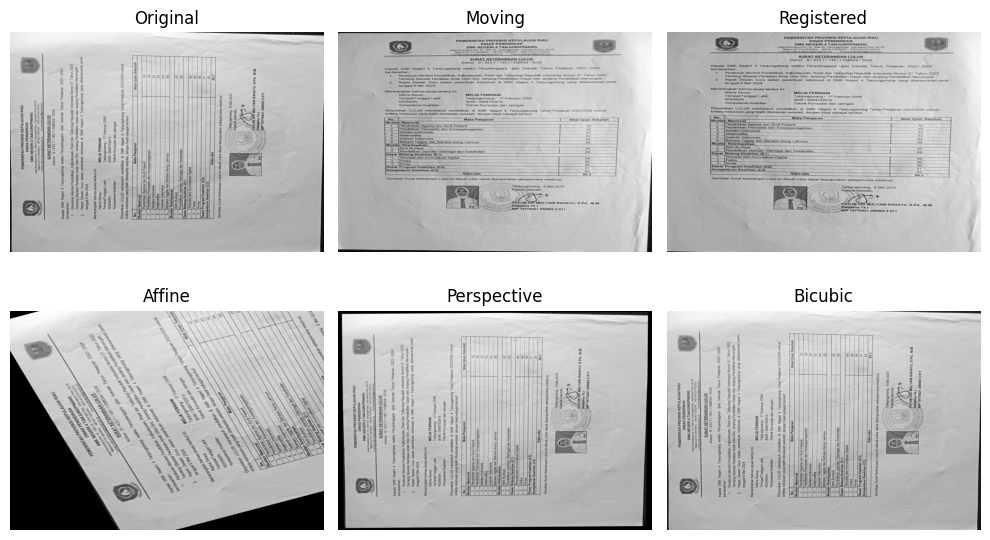

In [4]:
# ============================================
# PIPELINE TRANSFORMASI GEOMETRIK (SINGKAT)
# ============================================

from google.colab import files
import cv2, numpy as np, matplotlib.pyplot as plt, time

# ============================================
# 1. UPLOAD 2 GAMBAR
# ============================================

print("Upload 2 gambar (lurus & miring)")
uploaded = files.upload()

paths = list(uploaded.keys())

if len(paths) < 2:
    raise Exception("Upload minimal 2 gambar!")

# baca gambar grayscale
img1 = cv2.imdecode(np.frombuffer(uploaded[paths[0]], np.uint8), cv2.IMREAD_GRAYSCALE)
img2 = cv2.imdecode(np.frombuffer(uploaded[paths[1]], np.uint8), cv2.IMREAD_GRAYSCALE)

# samakan ukuran
h, w = img1.shape
img2 = cv2.resize(img2, (w, h))

# ============================================
# 2. MSE & PSNR
# ============================================

def mse(a,b): return np.mean((a.astype(float)-b.astype(float))**2)
def psnr(a,b): return 100 if mse(a,b)==0 else 10*np.log10((255**2)/mse(a,b))

# ============================================
# 3. TRANSFORMASI
# ============================================

def transform(img, M, type='affine'):
    start = time.time()
    if type == 'affine':
        out = cv2.warpAffine(img, M, (w,h))
    else:
        out = cv2.warpPerspective(img, M, (w,h))
    return out, time.time()-start

# Translasi
trans, t1 = transform(img1, np.float32([[1,0,40],[0,1,30]]))

# Rotasi
rot, t2 = transform(img1, cv2.getRotationMatrix2D((w//2,h//2),30,1))

# Scaling
start=time.time()
scale = cv2.resize(img1, None, fx=1.5, fy=1.5)
scale = cv2.resize(scale,(w,h))
t3=time.time()-start

# Affine (3 titik)
pts1 = np.float32([[50,50],[200,50],[50,200]])
pts2 = np.float32([[10,100],[200,50],[100,250]])
affine, t4 = transform(img1, cv2.getAffineTransform(pts1,pts2))

# Perspektif (4 titik)
pts1 = np.float32([[0,0],[w,0],[w,h],[0,h]])
pts2 = np.float32([[20,20],[w-20,10],[w-30,h-20],[30,h-10]])
pers, t5 = transform(img1, cv2.getPerspectiveTransform(pts1,pts2),'pers')

# ============================================
# 4. INTERPOLASI
# ============================================

interp = {}
for name, method in {
    "Nearest":cv2.INTER_NEAREST,
    "Bilinear":cv2.INTER_LINEAR,
    "Bicubic":cv2.INTER_CUBIC}.items():

    start=time.time()
    small=cv2.resize(img1,(w//2,h//2),interpolation=method)
    up=cv2.resize(small,(w,h),interpolation=method)
    interp[name]=(up, mse(img1,up), psnr(img1,up), time.time()-start)

# ============================================
# 5. REGISTRASI (ALIGN IMG2 KE IMG1)
# ============================================

# contoh sederhana pakai perspektif manual
M = cv2.getPerspectiveTransform(
    np.float32([[0,0],[w,0],[w,h],[0,h]]),
    np.float32([[20,20],[w-20,10],[w-30,h-20],[30,h-10]])
)
registered = cv2.warpPerspective(img2, np.linalg.inv(M), (w,h))

# ============================================
# 6. HASIL
# ============================================

print("\n=== TRANSFORMASI ===")
for name, img, t in [
    ("Translasi",trans,t1),("Rotasi",rot,t2),
    ("Scaling",scale,t3),("Affine",affine,t4),
    ("Perspektif",pers,t5)]:

    print(f"{name:10} | MSE:{mse(img1,img):.2f} | PSNR:{psnr(img1,img):.2f} | Time:{t:.4f}")

print("\n=== INTERPOLASI ===")
for k,(img,m,p,t) in interp.items():
    print(f"{k:10} | MSE:{m:.2f} | PSNR:{p:.2f} | Time:{t:.4f}")

# ============================================
# 7. VISUALISASI
# ============================================

def show(title,img,pos):
    plt.subplot(2,3,pos)
    plt.imshow(img,cmap='gray')
    plt.title(title)
    plt.axis('off')

plt.figure(figsize=(10,6))
show("Original",img1,1)
show("Moving",img2,2)
show("Registered",registered,3)
show("Affine",affine,4)
show("Perspective",pers,5)
show("Bicubic",interp["Bicubic"][0],6)

plt.tight_layout()
plt.show()